In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")


In [ ]:
                                                          "Healthcare Dataset Overview"

In [3]:
df=pd.read_csv("healthcare_dataset.csv")
df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
                                                 "Statistical Summary of Numerical Features"

In [5]:
df.shape          # rows, columns
df.columns        # column names
df.info()         # datatype + null values
df.describe()     # statistics

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

,Age,Billing Amount,Room Number
count,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829
std,19.602454,14211.454431,115.243069
min,13.000000,-2008.492140,101.000000
25%,35.000000,13241.224652,202.000000
50%,52.000000,25538.069376,302.000000
75%,68.000000,37820.508436,401.000000
max,89.000000,52764.276736,500.000000


In [7]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

In [ ]:
                                                                  "Missing values"

In [9]:
df.isnull().sum()

name                  0
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
doctor                0
hospital              0
insurance_provider    0
billing_amount        0
room_number           0
admission_type        0
discharge_date        0
medication            0
test_results          0
dtype: int64

In [11]:
df['name'] = df['name'].str.title()
df['gender'] = df['gender'].str.capitalize()

In [13]:
df['date_of_admission'] = pd.to_datetime(df['date_of_admission'])
df['discharge_date'] = pd.to_datetime(df['discharge_date'])

In [15]:
# hospital stay duration
df['stay_days'] = (df['discharge_date'] - df['date_of_admission']).dt.days

In [ ]:
                                                               "EDA (Exploratory Data Analysis)."

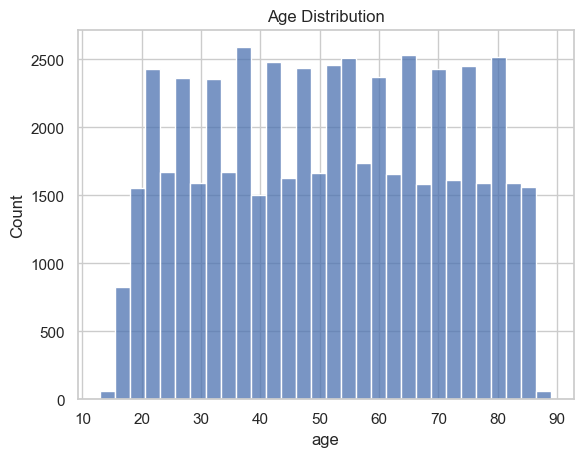

In [17]:
plt.figure()
sns.histplot(df['age'], bins=30)
plt.title("Age Distribution")
plt.show()

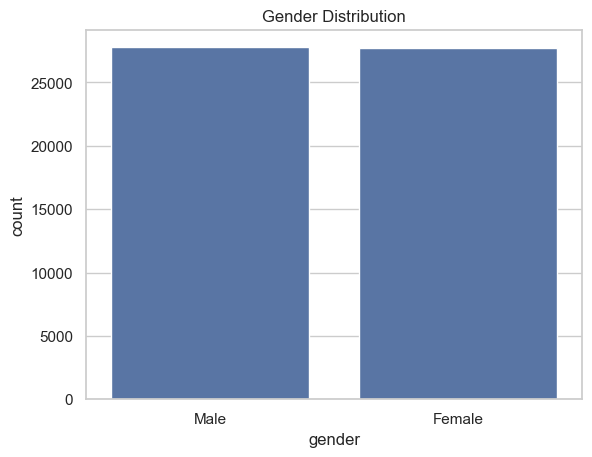

In [19]:
sns.countplot(x='gender', data=df)
plt.title("Gender Distribution")
plt.show()

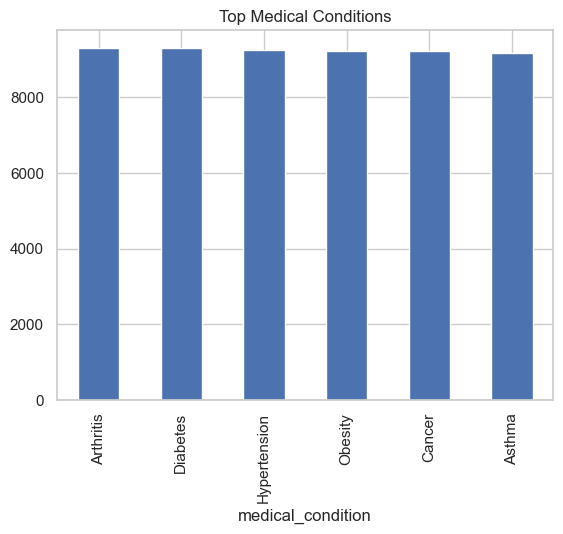

In [21]:
df['medical_condition'].value_counts().head(10).plot(kind='bar')
plt.title("Top Medical Conditions")
plt.show()

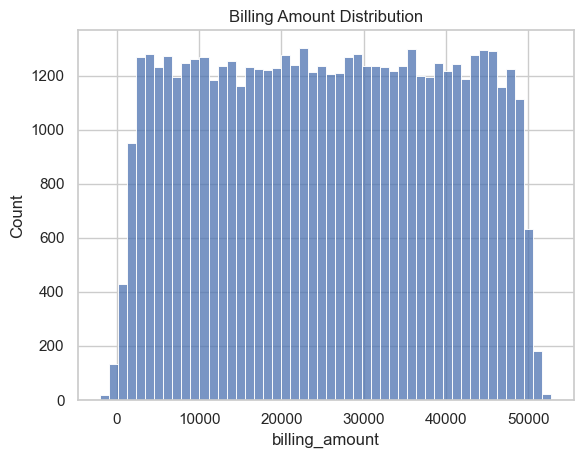

In [23]:
sns.histplot(df['billing_amount'], bins=50)
plt.title("Billing Amount Distribution")
plt.show()

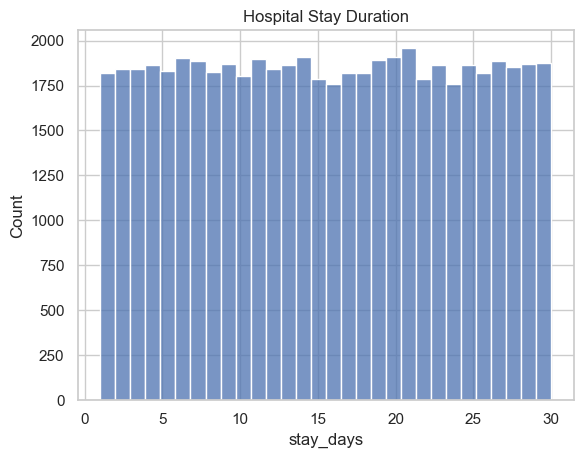

In [25]:
sns.histplot(df['stay_days'], bins=30)
plt.title("Hospital Stay Duration")
plt.show()

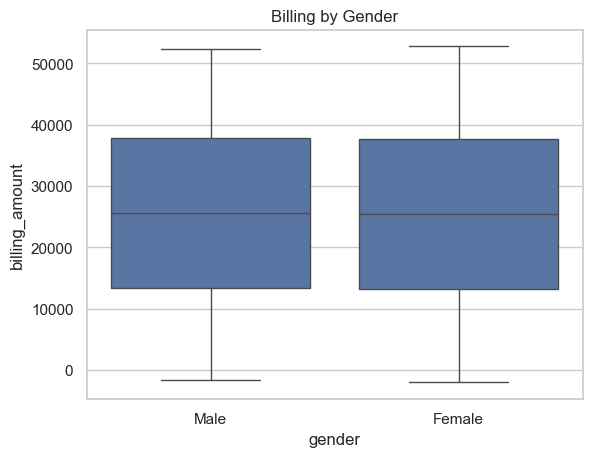

In [27]:
sns.boxplot(x='gender', y='billing_amount', data=df)
plt.title("Billing by Gender")
plt.show()

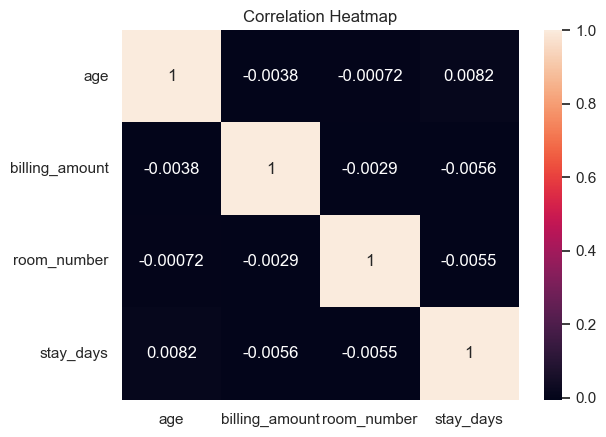

In [29]:
corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

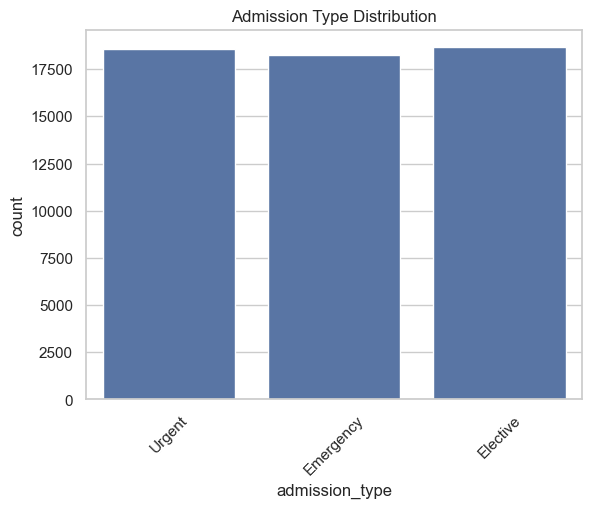

In [31]:
sns.countplot(x='admission_type', data=df)
plt.xticks(rotation=45)
plt.title("Admission Type Distribution")
plt.show()

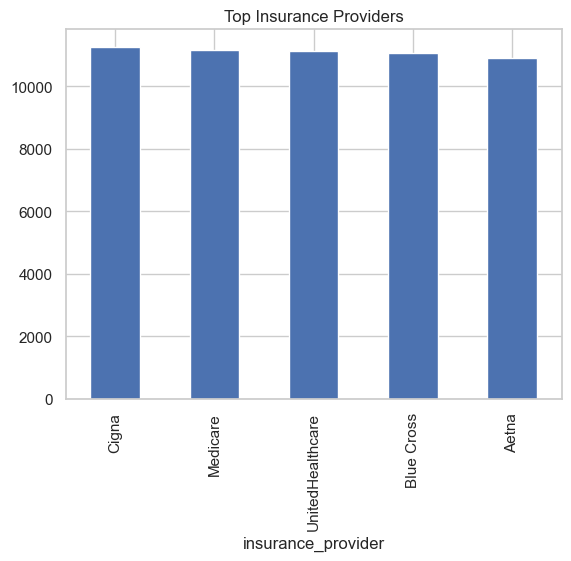

In [33]:
df['insurance_provider'].value_counts().head(10).plot(kind='bar')
plt.title("Top Insurance Providers")
plt.show()

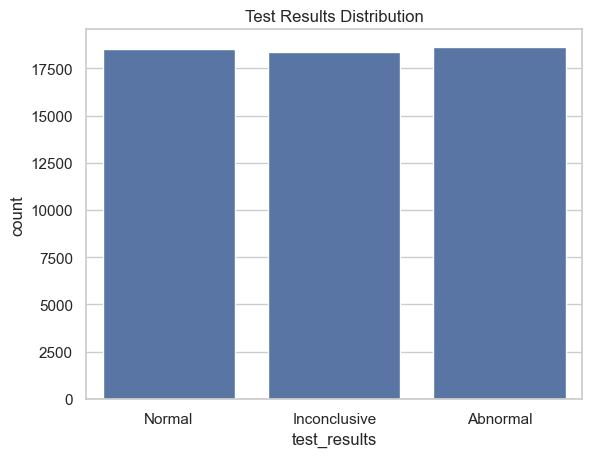

In [35]:
sns.countplot(x='test_results', data=df)
plt.title("Test Results Distribution")
plt.show()

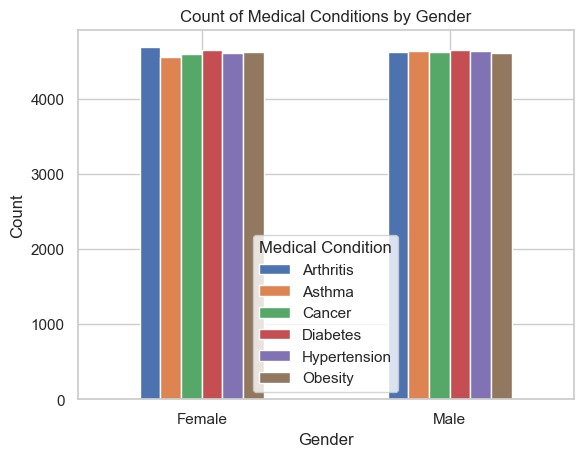

In [43]:
import matplotlib.pyplot as plt

# group the data
df_group = df.groupby(['gender', 'medical_condition']).size().unstack()

# plot
df_group.plot(kind='bar')

# labels
plt.title("Count of Medical Conditions by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.legend(title="Medical Condition")

plt.show()

In [45]:
df.to_csv("cleaned_healthcare_data.csv", index=False)

In [ ]:
                                                               "Insights"

In [ ]:


- Most patients fall between the age group of 30–50, indicating that middle-aged individuals visit hospitals more frequently.

- The number of male and female patients is almost equal, showing balanced gender distribution.

- Certain medical conditions (such as diabetes and hypertension) are more prevalent, indicating common chronic health issues.

- Higher billing amounts are strongly associated with longer hospital stays, suggesting increased treatment complexity.

- A few patients have extremely high billing amounts, indicating outliers or critical/long-term treatments.

- The average hospital stay is around X days, representing the typical treatment duration.

- Emergency admissions appear to have higher billing amounts compared to planned admissions.

- Patients with severe medical conditions tend to stay longer in the hospital.

- Some insurance providers cover a higher number of patients, indicating their popularity or wider acceptance.

- Billing amounts vary significantly across different medical conditions, showing cost differences in treatments.

- Older patients (above 60) tend to have longer hospital stays compared to younger patients.

